# *NLP (RESUME CLASSIFICATION)*

##  Importing Libraries

Import all the required libraries needed for file handling, data processing, and resume text extraction.
- `warnings` — suppresses unnecessary runtime warnings
- `os`, `zipfile`, `shutil` — for file system operations
- `docx`, `PyPDF2` — for reading Word and PDF resume files
- `pandas` — for data manipulation and DataFrame creation
- `Counter` — to count file extensions


In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import zipfile
import shutil
from docx import Document
import PyPDF2
import pandas as pd
from collections import Counter

In [2]:
#free up unused memory before starting the data loading process
import gc
gc.collect()

0

## Extracting ZIP File & Verifying Resume Files
  
The ZIP file containing resumes is extracted to a local folder (`extracted_resumes`). The code then walks through all subdirectories to count and verify the `.docx` and `.pdf` files present.



In [3]:
import os
zip_file_name = os.path.join(os.getcwd(), "Resume.zip")

extract_path = "extracted_resumes"

# Extract and overwrite existing files
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify correct count
all_files = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith('.docx') or file.endswith('.pdf'):
            all_files.append(file)

print(f"Total valid files: {len(all_files)}")
print("Extensions:", Counter([os.path.splitext(f)[1] for f in all_files]))

Total valid files: 53
Extensions: Counter({'.docx': 52, '.pdf': 1})


## 📄Text Extraction Function (`get_text`)
 
A utility function `get_text()` is defined to extract raw text from `.docx` and `.pdf` files.
For Word files, it joins all paragraph texts. For PDFs, it reads page by page using `PyPDF2.PdfReader`.

In [4]:
# Function to read text from Word and PDF files
from docx import Document
import PyPDF2

def get_text(file_path):
    # Extract text from Word files
    if file_path.endswith('.docx'):
        doc = Document(file_path)
        return " ".join([para.text for para in doc.paragraphs])
    
    # Extract text from PDF files
    elif file_path.endswith('.pdf'):
        text = ""
        with open(file_path, 'rb') as f:
            reader = PyPDF2.PdfReader(f)
            for page in reader.pages:
                text += page.extract_text()
        return text
    return ""

## 🗂️ Building the Dataset (DataFrame)

 
Resumes are loaded from the extracted folder, categorized by their parent subfolder name, and stored in a list of dictionaries. The data is then converted into a pandas DataFrame with columns: `Resume_Text`, `Category`, and `File_Name`.


In [5]:
data = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        file_path = os.path.join(root, file)
        file_ext = os.path.splitext(file)[1].lower()
        folder_name = os.path.basename(root)
        category = folder_name if root != extract_path else "Others"

        if file_ext in ['.docx', '.pdf']:
            resume_text = get_text(file_path)
            data.append({'Resume_Text': resume_text, 'Category': category, 'File_Name': file})

df = pd.DataFrame(data)
print("Total Resumes:", len(df))
print(df['Category'].value_counts())



Total Resumes: 53
Category
Resumes                            21
SQL Developer Lightning insight    11
workday resumes                    11
Peoplesoft resumes                 10
Name: count, dtype: int64


## 🏷️ Category Label Normalization


Folder names are mapped to cleaner category labels using `.replace()`:
- `"Resumes"` → `"General_Developer"`
- `"SQL Developer Lightning insight"` → `"SQL_Developer"`
- `"workday resumes"` → `"Workday"`
- `"Peoplesoft resumes"` → `"Peoplesoft"`


In [6]:
df["Category"] = df["Category"].replace({
    "Resumes": "General_Developer",
    "SQL Developer Lightning insight": "SQL_Developer",
    "workday resumes": "Workday",
    "Peoplesoft resumes": "Peoplesoft"
})
print(df['Category'].value_counts())


Category
General_Developer    21
SQL_Developer        11
Workday              11
Peoplesoft           10
Name: count, dtype: int64


## 💾  Saving Dataset to CSV


The processed DataFrame is saved as a CSV file (`resumes_final_dataset.csv`) with UTF-8-BOM encoding (`utf-8-sig`), which ensures compatibility with Excel and other tools.

In [7]:
df.to_csv('resumes_final_dataset.csv', index=False, encoding='utf-8-sig')
print("Saved successfully. Total records:", len(df))

Saved successfully. Total records: 53


## 🔍 Basic EDA — Shape, Nulls, Duplicates


This section checks the basic quality of the DataFrame:
- `.shape` — total rows and columns
- `.isnull().sum()` — missing values per column
- `.duplicated().sum()` — exact duplicate rows
- `.info()` — data types and memory usage


In [8]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())
df.info()

(53, 3)
Resume_Text    0
Category       0
File_Name      0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Resume_Text  53 non-null     object
 1   Category     53 non-null     object
 2   File_Name    53 non-null     object
dtypes: object(3)
memory usage: 1.4+ KB


In [9]:
print("Before:", len(df))
df = df.drop_duplicates(subset=["Resume_Text"])
print("After:", len(df))
print(df['Category'].value_counts())

Before: 53
After: 53
Category
General_Developer    21
SQL_Developer        11
Workday              11
Peoplesoft           10
Name: count, dtype: int64


##  Removing Duplicate Resumes

Duplicate rows are removed based on the `Resume_Text` column. The before/after count confirms how many duplicates were found. Category distribution is printed after deduplication.

In [10]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

df["clean_resume"] = df["Resume_Text"].apply(clean_text)
print("Text cleaning done.")
df.head()

Text cleaning done.


,Resume_Text,Category,File_Name,clean_resume
0,Name: Ravali P ...,General_Developer,Internship_Ravali_Musquare Technologies (1).docx,name ravali p curriculum vitae specialization ...
1,SUSOVAN BAG Seeking a challenging po...,General_Developer,Internship_Susovan Bag_Musquare Technologies.docx,susovan bag seeking a challenging position in...
2,Kanumuru Deepak Reddy CAREER OBJECTIVE: To...,General_Developer,React Developer_Deepakreddy.docx,kanumuru deepak reddy career objective to secu...
3,HARIPRIYA BATTINA Experience as UI Developer ...,General_Developer,React Developer_Haripriya.docx,haripriya battina experience as ui developer i...
4,KAMALAKAR REDDY. A Linked In: https://www.lin...,General_Developer,React Developer_Kamalakar Reddy.docx,kamalakar reddy a linked in www linkedin com ...


##  Text Cleaning (`clean_text`)

Remove common English stopwords from the cleaned resume text and store the result in a new column.

The `clean_text()` function applies several preprocessing steps:
- Lowercases all text
- Removes newlines, special characters, URLs, mentions, hashtags, and extra whitespace
- Creates a new column `clean_resume`


In [11]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if isinstance(text, str):
         words = text.split()
         filtered = [word for word in words if word not in stop_words]
         return " ".join(filtered)
    return text

    
df["clean_resume_no_stop"] = df["clean_resume"].apply(remove_stopwords)
print("Stopwords removed.")
df.head()

Stopwords removed.


[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


,Resume_Text,Category,File_Name,clean_resume,clean_resume_no_stop
0,Name: Ravali P ...,General_Developer,Internship_Ravali_Musquare Technologies (1).docx,name ravali p curriculum vitae specialization ...,name ravali p curriculum vitae specialization ...
1,SUSOVAN BAG Seeking a challenging po...,General_Developer,Internship_Susovan Bag_Musquare Technologies.docx,susovan bag seeking a challenging position in...,susovan bag seeking challenging position field...
2,Kanumuru Deepak Reddy CAREER OBJECTIVE: To...,General_Developer,React Developer_Deepakreddy.docx,kanumuru deepak reddy career objective to secu...,kanumuru deepak reddy career objective secure ...
3,HARIPRIYA BATTINA Experience as UI Developer ...,General_Developer,React Developer_Haripriya.docx,haripriya battina experience as ui developer i...,haripriya battina experience ui developer reac...
4,KAMALAKAR REDDY. A Linked In: https://www.lin...,General_Developer,React Developer_Kamalakar Reddy.docx,kamalakar reddy a linked in www linkedin com ...,kamalakar reddy linked www linkedin com kamala...


##  Stopword Removal


NLTK's English stopwords are used to remove common words (like "the", "is", "and") that don't add meaning for classification. A new column `clean_resume_no_stop` is created.


##  Resume Length Analysis

Word count per resume is calculated and stored in `resume_length`. Descriptive statistics (mean, min, max, etc.) are printed to understand the distribution of resume lengths.


In [12]:
df["resume_length"] = df["clean_resume"].apply(lambda x: len(x.split()))
print("Before cleaning:", len(df))
print(df["resume_length"].describe())

Before cleaning: 53
count      53.000000
mean      544.452830
std       334.393858
min       132.000000
25%       335.000000
50%       508.000000
75%       626.000000
max      2107.000000
Name: resume_length, dtype: float64


### *VISUALIZATION*

## Category Distribution Bar Chart

A bar chart shows the count of resumes per category. This gives a quick visual check for class imbalance in the dataset.

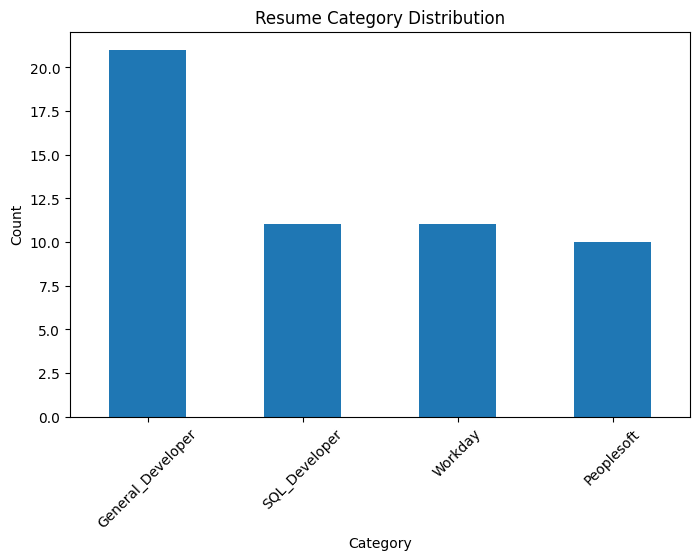

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
df["Category"].value_counts().plot(kind="bar")
plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

##  Resume Length Distribution (Histogram)


A histogram shows how word counts are distributed across all resumes. This helps detect outliers (very short or very long resumes) and understand the typical resume length.

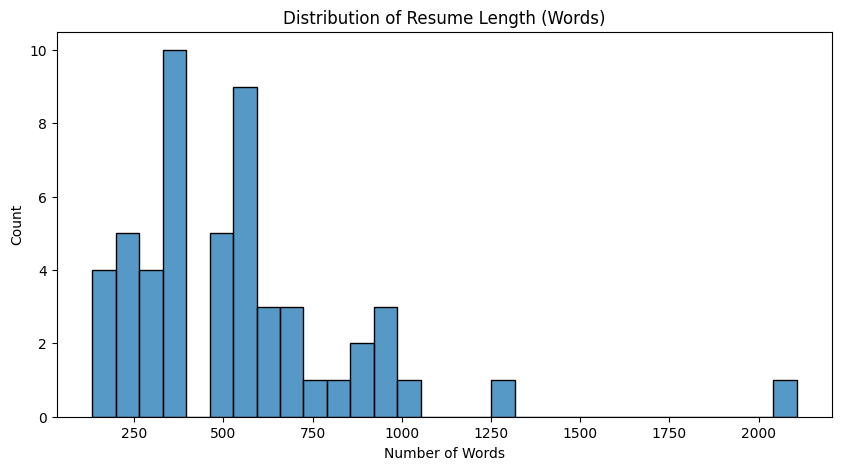

In [14]:
df["resume_length"] = df["clean_resume"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(df["resume_length"], bins=30)
plt.title("Distribution of Resume Length (Words)")
plt.xlabel("Number of Words")
plt.show()

##  Resume Length by Category (Boxplot)

A boxplot compares resume lengths across categories, revealing median, spread, and outliers per category.


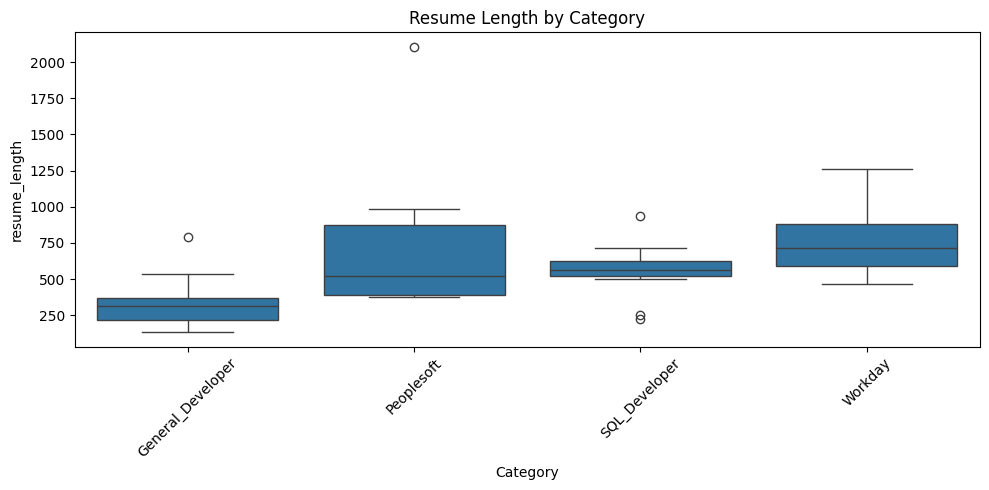

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Category", y="resume_length", data=df)
plt.title("Resume Length by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  Category Distribution Pie Chart


A pie chart provides another view of category proportions. It shows the percentage share of each resume category.

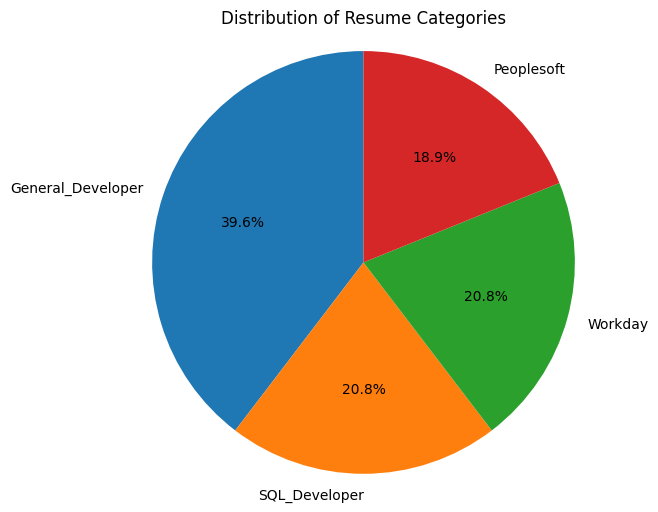

In [16]:
category_counts = df["Category"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Resume Categories")
plt.axis('equal')
plt.show()

## Overall Word Cloud

A word cloud is generated from all cleaned resumes combined. Larger words appear more frequently across the entire dataset.



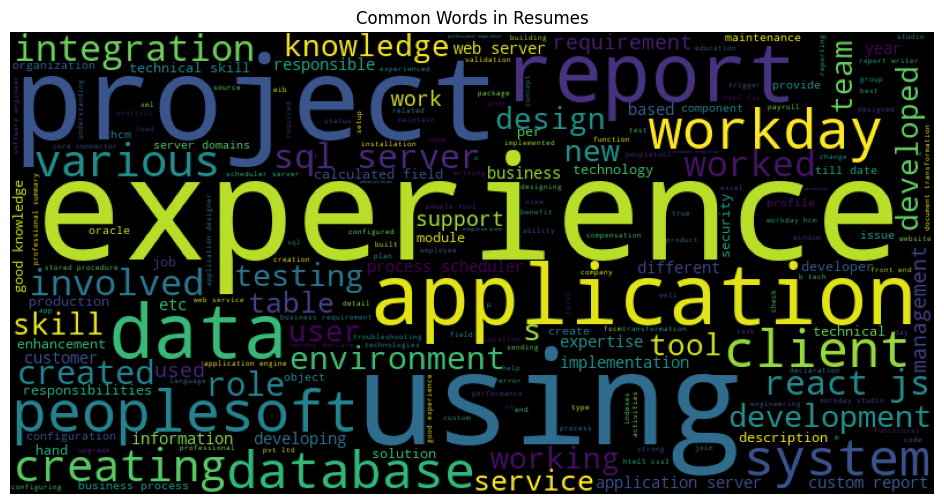

In [17]:
from wordcloud import WordCloud

text = " ".join(df["clean_resume"])
wc = WordCloud(width=800, height=400, background_color="black").generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.title("Common Words in Resumes")
plt.show()

## Per-Category Word Clouds

Separate word clouds are generated for each category using `clean_resume_no_stop`. This reveals the most distinctive vocabulary per category (e.g., "workday", "peoplesoft", "sql").


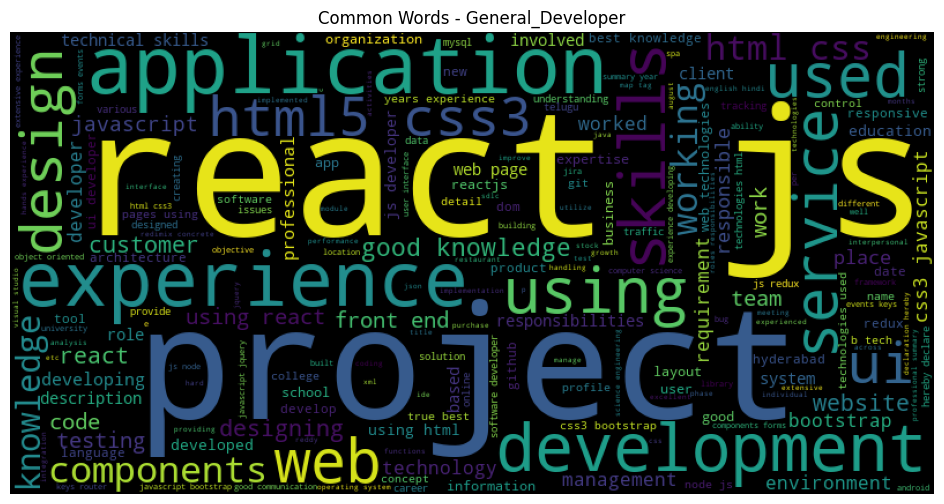

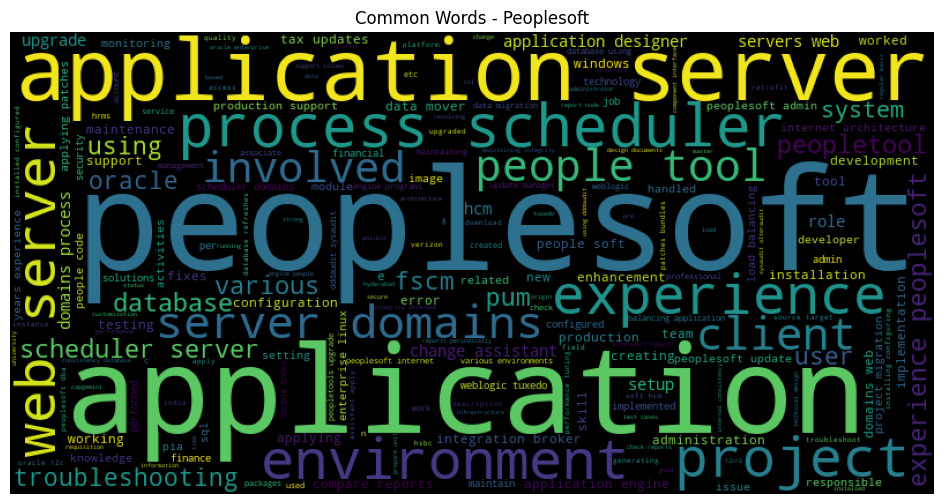

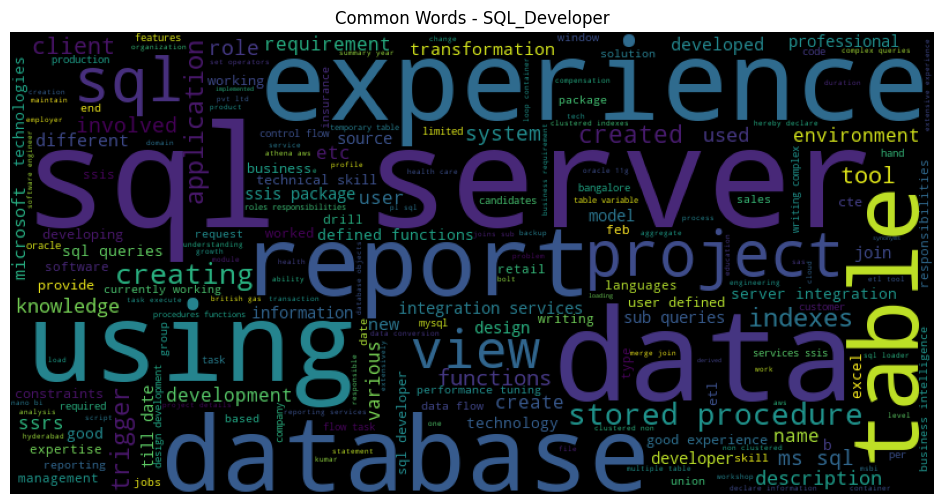

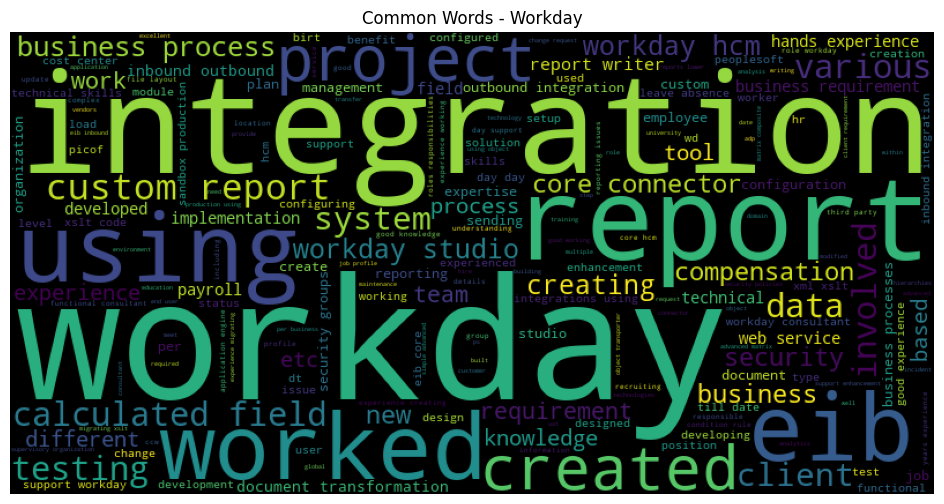

In [18]:
for category in df["Category"].unique():
    text = " ".join(df[df["Category"] == category]["clean_resume_no_stop"])
    wc = WordCloud(width=800, height=400, background_color="Black").generate(text)
    plt.figure(figsize=(12,6))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Common Words - {category}")
    plt.show()

## feature extraction

### Label Encoding

`LabelEncoder` converts categorical class names into numeric labels (0, 1, 2, 3). The mapping is printed to verify correctness.

Convert the cleaned resume text into a numerical TF-IDF feature matrix.

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Category_Encoded"] = le.fit_transform(df["Category"])

print("Category Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

Category Mapping:
  0 → General_Developer
  1 → Peoplesoft
  2 → SQL_Developer
  3 → Workday


##  TF-IDF Feature Extraction

`TfidfVectorizer` converts cleaned resume text into a numerical feature matrix of shape `(n_samples, 500)`. The top 500 features (words) are selected based on TF-IDF scores.


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)
X = tfidf.fit_transform(df["clean_resume_no_stop"])
y = df["Category_Encoded"]
print("Feature matrix shape:", X.shape)

Feature matrix shape: (53, 500)


##  Train-Test Split

The dataset is split into 80% training and 20% testing using `stratify=y` to maintain class proportions in both sets.


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (42, 500)
Testing size: (11, 500)


##  Model Comparison via Cross-Validation

Four classifiers are evaluated using 5-fold cross-validation: Random Forest, SVM (LinearSVC), Logistic Regression, and XGBoost. Mean accuracy and standard deviation are printed for each.


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": LinearSVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean().round(2)} ± {scores.std().round(2)}")
    

Random Forest: 1.0 ± 0.0
SVM: 1.0 ± 0.0
Logistic Regression: 0.94 ± 0.08
XGBoost: 0.95 ± 0.07


## Final SVM Model Training & Evaluation

The best model (LinearSVC / SVM) is trained on the training set and evaluated on the test set. A classification report (precision, recall, F1) and confusion matrix heatmap are generated.


                   precision    recall  f1-score   support

General_Developer       1.00      1.00      1.00         5
       Peoplesoft       1.00      1.00      1.00         2
    SQL_Developer       1.00      1.00      1.00         2
          Workday       1.00      1.00      1.00         2

         accuracy                           1.00        11
        macro avg       1.00      1.00      1.00        11
     weighted avg       1.00      1.00      1.00        11



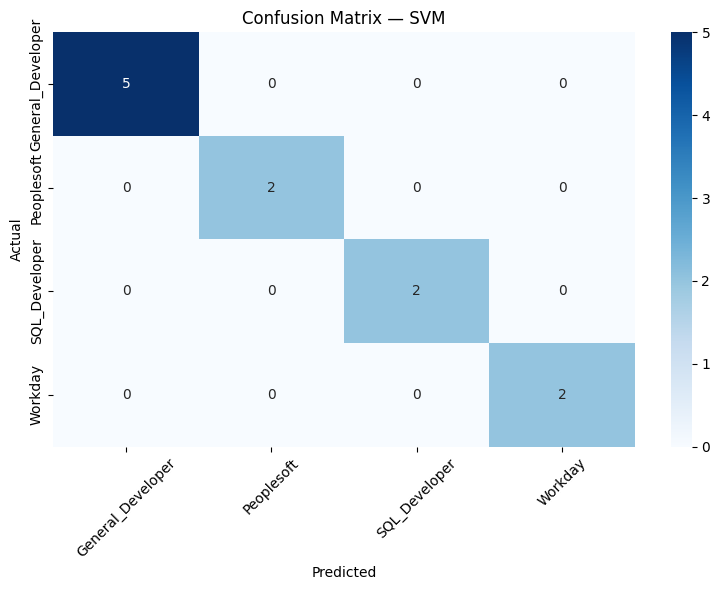

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Confusion Matrix — SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  Manual Prediction Test

Four custom resume text snippets are tested against the trained SVM model to verify that predictions are sensible. Each input is transformed using the fitted TF-IDF vectorizer before prediction.


In [24]:
test_samples = [
    "experience in workday hcm integration reports eib custom",
    "sql server database queries stored procedures tables functions",
    "peoplesoft application server hrms administration",
    "react javascript frontend developer component hooks"
]

for text in test_samples:
    vec = tfidf.transform([text])
    pred = svm.predict(vec)
    print(f"Text: {text[:40]}... → Predicted: {le.inverse_transform(pred)[0]}")

Text: experience in workday hcm integration re... → Predicted: Workday
Text: sql server database queries stored proce... → Predicted: SQL_Developer
Text: peoplesoft application server hrms admin... → Predicted: Peoplesoft
Text: react javascript frontend developer comp... → Predicted: General_Developer


##  Saving Model Components

 
The three model components are saved using `joblib`:
- `svm_model.pkl` — trained classifier
- `tfidf_vectorizer.pkl` — fitted TF-IDF transformer
- `label_encoder.pkl` — encoder for decoding predictions


In [25]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(svm,   'models/svm_model.pkl')
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
joblib.dump(le,    'models/label_encoder.pkl')

print('✅ Model components saved to /models/')
print('  - svm_model.pkl')
print('  - tfidf_vectorizer.pkl')
print('  - label_encoder.pkl')

✅ Model components saved to /models/
  - svm_model.pkl
  - tfidf_vectorizer.pkl
  - label_encoder.pkl
